# Top 50 Spotify Tracks in 2020
# Exploratory Data Analysis

# About the Project


*   The goal of this project is to answer the question "What makes a hit song".

*   In this exploratory data analysis we accomplish this goal by identifying patterns and trends.

*   We want to determine which of the features are mandatory of the hit song and which of the features are optional.



# Agenda



1.   Handling missing/duplicate data, identifying outliers.
2.   Exploring the data to identify trends
3.   Checking for correlations between features and genres.





# Overview of the Dataset

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
"""
Loading data into dataframe
"""
df = pd.read_csv("spotifytoptracks.csv", index_col=0)

In [3]:
"""
First 5 row
"""
df.head()

,artist,album,track_name,track_id,energy,danceability,key,loudness,acousticness,speechiness,instrumentalness,liveness,valence,tempo,duration_ms,genre
0,The Weeknd,After Hours,Blinding Lights,0VjIjW4GlUZAMYd2vXMi3b,0.730,0.514,1,-5.934,0.00146,0.0598,0.000095,0.0897,0.334,171.005,200040,R&B/Soul
1,Tones And I,Dance Monkey,Dance Monkey,1rgnBhdG2JDFTbYkYRZAku,0.593,0.825,6,-6.401,0.68800,0.0988,0.000161,0.1700,0.540,98.078,209755,Alternative/Indie
2,Roddy Ricch,Please Excuse Me For Being Antisocial,The Box,0nbXyq5TXYPCO7pr3N8S4I,0.586,0.896,10,-6.687,0.10400,0.0559,0.000000,0.7900,0.642,116.971,196653,Hip-Hop/Rap
3,SAINt JHN,Roses (Imanbek Remix),Roses - Imanbek Remix,2Wo6QQD1KMDWeFkkjLqwx5,0.721,0.785,8,-5.457,0.01490,0.0506,0.004320,0.2850,0.894,121.962,176219,Dance/Electronic
4,Dua Lipa,Future Nostalgia,Don't Start Now,3PfIrDoz19wz7qK7tYeu62,0.793,0.793,11,-4.521,0.01230,0.0830,0.000000,0.0951,0.679,123.950,183290,Nu-disco


In [4]:
"""
Data types
"""
df.dtypes

,0
artist,object
album,object
track_name,object
track_id,object
energy,float64
danceability,float64
key,int64
loudness,float64
acousticness,float64
speechiness,float64


In [5]:
"""
Summary statistics
"""
df.describe()

,energy,danceability,key,loudness,acousticness,speechiness,instrumentalness,liveness,valence,tempo,duration_ms
count,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000
mean,0.609300,0.716720,5.720000,-6.225900,0.256206,0.124158,0.015962,0.196552,0.555710,119.690460,199955.360000
std,0.154348,0.124975,3.709007,2.349744,0.265250,0.116836,0.094312,0.176610,0.216386,25.414778,33996.122488
min,0.225000,0.351000,0.000000,-14.454000,0.001460,0.029000,0.000000,0.057400,0.060500,75.801000,140526.000000
25%,0.494000,0.672500,2.000000,-7.552500,0.052800,0.048325,0.000000,0.093950,0.434000,99.557250,175845.500000
50%,0.597000,0.746000,6.500000,-5.991500,0.188500,0.070050,0.000000,0.111000,0.560000,116.969000,197853.500000
75%,0.729750,0.794500,8.750000,-4.285500,0.298750,0.155500,0.000020,0.271250,0.726250,132.317000,215064.000000
max,0.855000,0.935000,11.000000,-3.280000,0.934000,0.487000,0.657000,0.792000,0.925000,180.067000,312820.000000


# Data Cleaning

In [6]:
"""
Checking for the NaN values in the dataset
"""
df.isna().any()

,0
artist,False
album,False
track_name,False
track_id,False
energy,False
danceability,False
key,False
loudness,False
acousticness,False
speechiness,False


In [7]:
"""
Checking for duplicate data
"""
df.duplicated().any()

np.False_

In [8]:
"""
Checking for outliers

First - we need a boolean value whether
a value in spotify dataframe is an outlier.

Second - we need to make an empty dataframe
with highlighted cells that belong to
the outlier value from spotify dataframe.

Third - we apply the highlighting to the
spotify dataframe
"""
numeric_features = ["energy", "danceability", "loudness",
        "acousticness", "speechiness", "instrumentalness",
        "liveness", "valence", "tempo", "duration_ms"]
q1 = df[numeric_features].quantile(0.25)
q3 = df[numeric_features].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
outliers = (
    (df[numeric_features] < lower_bound) |
    (df[numeric_features] > upper_bound)
)

"""
Counting outliers
"""
outlier_count_df = outliers.sum().reset_index()
outlier_count_df.columns = ["feature", "outlier_count"]
display(outlier_count_df)
print("\n")

def outliers_highlight(data):
    empty_df = (
        pd.DataFrame(
            '', index=data.index, columns=data.columns
            )
    )
    empty_df[numeric_features] = (
        outliers.map(
            lambda x: "background-color: red" if x else ''
            )
    )
    return empty_df

df.style.apply(outliers_highlight, axis=None)

,feature,outlier_count
0,energy,0
1,danceability,3
2,loudness,1
3,acousticness,7
4,speechiness,6
5,instrumentalness,12
6,liveness,3
7,valence,0
8,tempo,0
9,duration_ms,2


,artist,album,track_name,track_id,energy,danceability,key,loudness,acousticness,speechiness,instrumentalness,liveness,valence,tempo,duration_ms,genre
0,The Weeknd,After Hours,Blinding Lights,0VjIjW4GlUZAMYd2vXMi3b,0.730000,0.514000,1,-5.934000,0.001460,0.059800,0.000095,0.089700,0.334000,171.005000,200040,R&B/Soul
1,Tones And I,Dance Monkey,Dance Monkey,1rgnBhdG2JDFTbYkYRZAku,0.593000,0.825000,6,-6.401000,0.688000,0.098800,0.000161,0.170000,0.540000,98.078000,209755,Alternative/Indie
2,Roddy Ricch,Please Excuse Me For Being Antisocial,The Box,0nbXyq5TXYPCO7pr3N8S4I,0.586000,0.896000,10,-6.687000,0.104000,0.055900,0.000000,0.790000,0.642000,116.971000,196653,Hip-Hop/Rap
3,SAINt JHN,Roses (Imanbek Remix),Roses - Imanbek Remix,2Wo6QQD1KMDWeFkkjLqwx5,0.721000,0.785000,8,-5.457000,0.014900,0.050600,0.004320,0.285000,0.894000,121.962000,176219,Dance/Electronic
4,Dua Lipa,Future Nostalgia,Don't Start Now,3PfIrDoz19wz7qK7tYeu62,0.793000,0.793000,11,-4.521000,0.012300,0.083000,0.000000,0.095100,0.679000,123.950000,183290,Nu-disco
5,DaBaby,BLAME IT ON BABY,ROCKSTAR (feat. Roddy Ricch),7ytR5pFWmSjzHJIeQkgog4,0.690000,0.746000,11,-7.956000,0.247000,0.164000,0.000000,0.101000,0.497000,89.977000,181733,Hip-Hop/Rap
6,Harry Styles,Fine Line,Watermelon Sugar,6UelLqGlWMcVH1E5c4H7lY,0.816000,0.548000,0,-4.209000,0.122000,0.046500,0.000000,0.335000,0.557000,95.390000,174000,Pop
7,Powfu,death bed (coffee for your head),death bed (coffee for your head),7eJMfftS33KTjuF7lTsMCx,0.431000,0.726000,8,-8.765000,0.731000,0.135000,0.000000,0.696000,0.348000,144.026000,173333,Hip-Hop/Rap
8,Trevor Daniel,Nicotine,Falling,2rRJrJEo19S2J82BDsQ3F7,0.430000,0.784000,10,-8.756000,0.123000,0.036400,0.000000,0.088700,0.236000,127.087000,159382,R&B/Hip-Hop alternative
9,Lewis Capaldi,Divinely Uninspired To A Hellish Extent,Someone You Loved,7qEHsqek33rTcFNT9PFqLf,0.405000,0.501000,1,-5.679000,0.751000,0.031900,0.000000,0.105000,0.446000,109.891000,182161,Alternative/Indie


*   None of the outliers look like data errors.

*   I chose to keep the outliers in the dataset but later on I'll use median rather than mean, as "average" value.

*   Because data seem to be mostly skewed, we'll use Spearman's method to measure correlation.




# Data Exploration

In [10]:
"""
How many observations (rows) are there in this dataset?
"""
len(df)

50

In [11]:
"""
How many features (columns) does this dataset have?
"""
len(df.columns)

16

In [12]:
"""
Which of the features are categorical?
"""
categorical_count = df.dtypes.astype(str).isin(['object']).sum()

print(categorical_count)

5


In [13]:
"""
Which of the features are numeric?
"""
numeric_count = df.dtypes.astype(str).isin(['float64', 'int64']).sum()

print(numeric_count)

11


In [14]:
"""
Are there any artists that have more than 1 popular track?
If yes, which, and how many?
"""
all_artists = df.artist.value_counts()
artists_with_multiple_entries = all_artists[all_artists > 1]
artists_df = (
    artists_with_multiple_entries
    .reset_index(name="song_count")
)
count_artists = artists_with_multiple_entries.count()

display(artists_df)
print(f"\n{count_artists} artists had multiple songs in top 50 list.")


,artist,song_count
0,Dua Lipa,3
1,Billie Eilish,3
2,Travis Scott,3
3,Harry Styles,2
4,Lewis Capaldi,2
5,Justin Bieber,2
6,Post Malone,2



7 artists had multiple songs in top 50 list.


In [15]:
"""
Who was the most popular artist?

Out of the artists with the most tracks in the top 50 chart,
I want to select the one who had the highest placing track.
"""
all_artists = df.artist.value_counts()
max_entries_by_artist = all_artists.max()
top_artists = all_artists[all_artists == max_entries_by_artist]
top_artists_names = top_artists.index
top_artists_df = (df.loc[
    df.artist.isin(top_artists_names)
    ].sort_index()
)
most_popular_artist = top_artists_df.artist.iloc[0]

print(f"{most_popular_artist} is the most popular artist.")

Dua Lipa is the most popular artist.


In [16]:
"""
How many artists have their songs in the top 50 in total?
"""
unique_artists = len(df.artist.unique())

print(f"{unique_artists} different artists appeared in the chart.")

40 different artists appeared in the chart.


In [17]:
"""
Are there any albums that have more than 1 popular track?
If yes, which, and how many?
"""
all_albums = df.album.value_counts()
albums_with_multiple_entries = all_albums[all_albums > 1]
albums_df = (
    albums_with_multiple_entries
    .reset_index(name="song_count")
)
count_albums = albums_with_multiple_entries.count()

display(albums_df)
print(
    f"\nNumber of tracks with a danceability score "
    f"over 0.7: {len(albums_with_multiple_entries)}.\n"
)

,album,song_count
0,Future Nostalgia,3
1,Hollywood's Bleeding,2
2,Fine Line,2
3,Changes,2



Number of tracks with a danceability score over 0.7: 4.



In [18]:
"""
How many albums in total have their songs in the top 50?
"""
unique_albums = len(df.album.unique())

print(
    f"{unique_albums} "
    f"different albums had songs featured on the list."
)

45 different albums had songs featured on the list.


In [19]:
"""
Which tracks have a danceability score above 0.7?
"""
dance_tracks = df.loc[df.danceability > 0.7]
filtered_dance_tracks = (
    dance_tracks.loc[
        :, ["artist", "track_name", "danceability"]
        ]
)

print(
    f"\nNumber of tracks with a danceability score "
    f"over 0.7: {len(dance_tracks)}.\n"
)
filtered_dance_tracks.sort_values(by="danceability", ascending=False)


Number of tracks with a danceability score over 0.7: 32.



,artist,track_name,danceability
27,Cardi B,WAP (feat. Megan Thee Stallion),0.935
2,Roddy Ricch,The Box,0.896
39,Regard,Ride It,0.880
28,Surfaces,Sunday Best,0.878
33,BENEE,Supalonely (feat. Gus Dapperton),0.862
40,Travis Scott,goosebumps,0.841
49,Travis Scott,SICKO MODE,0.834
15,Drake,Toosie Slide,0.830
1,Tones And I,Dance Monkey,0.825
29,Eminem,Godzilla (feat. Juice WRLD),0.808


In [20]:
"""
Which tracks have a danceability score below 0.4?
"""
non_dance_tracks = df.loc[df.danceability < 0.4]
filtered_non_dance_tracks = (
    non_dance_tracks.loc[
        :, ["artist", "track_name", "danceability"]
        ]
)

print(
    f"\nNumber of tracks with a danceability score "
    f"below 0.4: {len(non_dance_tracks)}.\n"
)
filtered_non_dance_tracks.sort_values(by="danceability")


Number of tracks with a danceability score below 0.4: 1.



,artist,track_name,danceability
44,Billie Eilish,lovely (with Khalid),0.351


In [21]:
"""
Which tracks have their loudness above -5?
"""
loud_tracks = df.loc[df.loudness > -5]
filtered_loud_tracks = (
    loud_tracks.loc[
        :, ["artist", "track_name", "loudness"]
        ]
)

print(
    f"\nNumber of tracks with a loudness score "
    f"over -5: {len(loud_tracks)}.\n"
)
filtered_loud_tracks.sort_values(by="loudness", ascending=False)


Number of tracks with a loudness score over -5: 19.



,artist,track_name,loudness
10,KAROL G,Tusa,-3.280
40,Travis Scott,goosebumps,-3.370
31,Dua Lipa,Break My Heart,-3.434
38,Maluma,Hawái,-3.454
12,Post Malone,Circles,-3.497
23,24kGoldn,Mood (feat. iann dior),-3.558
21,Harry Styles,Adore You,-3.675
49,Travis Scott,SICKO MODE,-3.714
48,Dua Lipa,Physical,-3.756
35,Lady Gaga,Rain On Me (with Ariana Grande),-3.764


In [22]:
"""
Which tracks have their loudness below -8?
"""
calm_tracks = df.loc[df.loudness < -8]
filtered_calm_tracks = (
    calm_tracks.loc[
        :, ["artist", "track_name", "loudness"]
        ]
)

print(
    f"\nNumber of tracks with a loudness score "
    f"below -8: {len(calm_tracks)}.\n"
)
filtered_calm_tracks.sort_values(by="loudness")


Number of tracks with a loudness score below -8: 9.



,artist,track_name,loudness
24,Billie Eilish,everything i wanted,-14.454
26,Billie Eilish,bad guy,-10.965
44,Billie Eilish,lovely (with Khalid),-10.109
47,JP Saxe,If the World Was Ending - feat. Julia Michaels,-10.086
15,Drake,Toosie Slide,-8.820
7,Powfu,death bed (coffee for your head),-8.765
36,Travis Scott,HIGHEST IN THE ROOM,-8.764
8,Trevor Daniel,Falling,-8.756
20,Jawsh 685,Savage Love (Laxed - Siren Beat),-8.520


In [23]:
"""
Which track is the longest?
"""
longest_track = df.loc[:, ["artist", "track_name", "duration_ms"]]

def format_time(row):
    duration_s = row["duration_ms"] // 1000
    minutes = duration_s // 60
    seconds = duration_s % 60
    return f"{minutes}:{seconds}"

longest_track["track_duration"] = (
    longest_track.apply(format_time, axis="columns")
)
(
    longest_track.sort_values(by="duration_ms", ascending=False)
    .drop(columns="duration_ms")
    .head(1)
)

,artist,track_name,track_duration
49,Travis Scott,SICKO MODE,5:12


In [24]:
"""
Which track is the shortest?
"""
shortest_track = df.loc[:, ["artist", "track_name", "duration_ms"]]

def format_time(row):
    duration_s = row["duration_ms"] // 1000
    minutes = duration_s // 60
    seconds = duration_s % 60
    return f"{minutes}:{seconds}"

shortest_track["track_duration"] = (
    shortest_track.apply(format_time, axis="columns")
)
(
    shortest_track.sort_values(by="duration_ms")
    .drop(columns="duration_ms")
    .head(1)
)

,artist,track_name,track_duration
23,24kGoldn,Mood (feat. iann dior),2:20


In [25]:
"""
Which genre is the most popular?
"""
all_genres = df.groupby("genre").genre.count()
most_popular_genre = all_genres.idxmax()
most_popular_count = all_genres.max()
print(
    f"{most_popular_genre} genre is the most "
    f"popular with {most_popular_count} tracks."
)

Pop genre is the most popular with 14 tracks.


In [26]:
"""
Which genres have just one song in the top 50?
"""
all_genres = df.groupby("genre").genre.count()
genres_with_1_song = all_genres[all_genres == 1]
genres_df = genres_with_1_song.reset_index(name="song_count")

print(
    f"\n{len(genres_with_1_song)} genres have just "
    f"one song on the chart.\n"
)
display(genres_df)


10 genres have just one song on the chart.



,genre,song_count
0,Alternative/reggaeton/experimental,1
1,Chamber pop,1
2,Dance-pop/Disco,1
3,Disco-pop,1
4,Dreampop/Hip-Hop/R&B,1
5,Hip-Hop/Trap,1
6,Nu-disco,1
7,Pop rap,1
8,Pop/Soft Rock,1
9,R&B/Hip-Hop alternative,1


In [27]:
"""
How many genres in total are represented in the top 50?
"""
all_genres = df.groupby("genre")

print(f"{len(all_genres)} genres are represented in the top 50 chart.")

16 genres are represented in the top 50 chart.


# Correlation Analysis



*   Spearman correlation was used to calculate the correlation between features

*   The threshold for a "strong" correlation was chosen to be 0.5.
*   Anything lower is not considered to be "strong" enough and anything higher risks missing trends that could important for an analysis with a larger sample size

*   The threshold for "no correlation" was chosen to be 0.1.
*   It's low enough to filter out all insignificant correlations.





In [39]:
"""
Which features are strongly positively correlated?
"""
numeric_features = ["energy", "danceability", "key", "loudness",
        "acousticness", "speechiness", "instrumentalness",
        "liveness", "valence", "tempo"]
filtered_df = df.loc[:, numeric_features]
corr_matrix = filtered_df.corr(method="spearman")
corr_matrix_lower = corr_matrix.where(
    np.tril(np.ones(corr_matrix.shape), k=-1).astype(bool)
)
filtered_matrix = corr_matrix_lower.where(corr_matrix_lower >= 0.5)

strong_positive_corr = filtered_matrix.unstack().dropna().reset_index()
strong_positive_corr.columns = ["feature_1", "feature_2", "correlation"]
strong_positive_corr

,feature_1,feature_2,correlation
0,energy,loudness,0.752383


In [37]:
"""
Which features are strongly negatively correlated?
"""
numeric_features = ["energy", "danceability", "key", "loudness",
        "acousticness", "speechiness", "instrumentalness",
        "liveness", "valence", "tempo"]
filtered_df = df.loc[:, numeric_features]
corr_matrix = filtered_df.corr(method="spearman")
corr_matrix_lower = corr_matrix.where(
    np.tril(np.ones(corr_matrix.shape), k=-1).astype(bool)
)
filtered_matrix = corr_matrix_lower.where(corr_matrix_lower <= -0.4)

strong_negative_corr = filtered_matrix.unstack().dropna().reset_index()
strong_negative_corr.columns = ["feature_1", "feature_2", "correlation"]
strong_negative_corr

,feature_1,feature_2,correlation
0,energy,acousticness,-0.655446


In [30]:
"""
Which features are not correlated?
"""
numeric_features = ["energy", "danceability", "key", "loudness",
        "acousticness", "speechiness", "instrumentalness",
        "liveness", "valence", "tempo"]
filtered_df = df.loc[:, numeric_features]
corr_matrix = filtered_df.corr(method="spearman")
corr_matrix_lower = corr_matrix.where(
    np.tril(np.ones(corr_matrix.shape), k=-1).astype(bool)
)
filtered_matrix = corr_matrix_lower.where(
    (corr_matrix_lower >= -0.1) &
    (corr_matrix_lower <= 0.1)
)

no_corr = filtered_matrix.unstack().dropna().reset_index()
no_corr.columns = ["feature_1", "feature_2", "correlation"]
no_corr

,feature_1,feature_2,correlation
0,energy,danceability,0.052969
1,energy,key,0.067692
2,energy,speechiness,0.084088
3,energy,tempo,0.071886
4,danceability,instrumentalness,0.024121
5,key,loudness,-0.034895
6,key,acousticness,-0.091704
7,key,speechiness,0.016483
8,key,instrumentalness,-0.028765
9,key,tempo,0.091751




*   Genres that were analyzed below are the 4 genres with the most songs in the top 50 chart.
*   Together they make up 72% of total songs



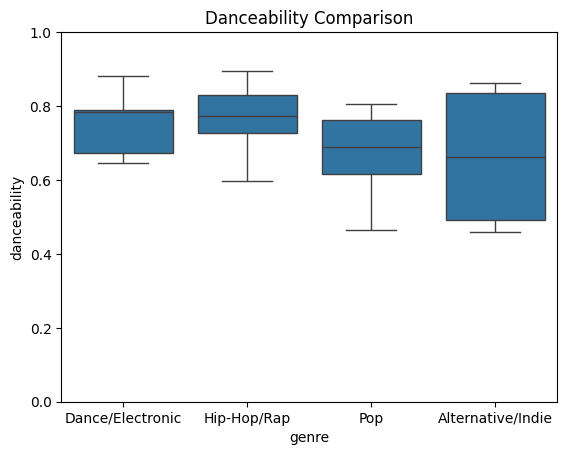

,genre,song_count
0,Pop,14
1,Hip-Hop/Rap,13
2,Dance/Electronic,5
3,Alternative/Indie,4


In [31]:
"""
How does the danceability score compare between
Pop, Hip-Hop/Rap, Dance/Electronic, and Alternative/Indie genres?
"""
relevant_genres = ["Pop", "Hip-Hop/Rap", "Dance/Electronic", "Alternative/Indie"]
filtered_df = df.loc[df.genre.isin(relevant_genres)]
danceability_comparison = (
    filtered_df.groupby(["genre"])
    .danceability.median()
    .sort_values(ascending=False)
    .index
)
sns.boxplot(
    data=filtered_df,
    x="genre",
    y="danceability",
    order=danceability_comparison
)
song_count_df = (
    filtered_df.groupby("genre")
    .genre.count()
    .sort_values(ascending=False)
    .reset_index(name="song_count")
)

plt.title("Danceability Comparison")
plt.ylim(0, 1)
plt.show()
print("\n")
song_count_df

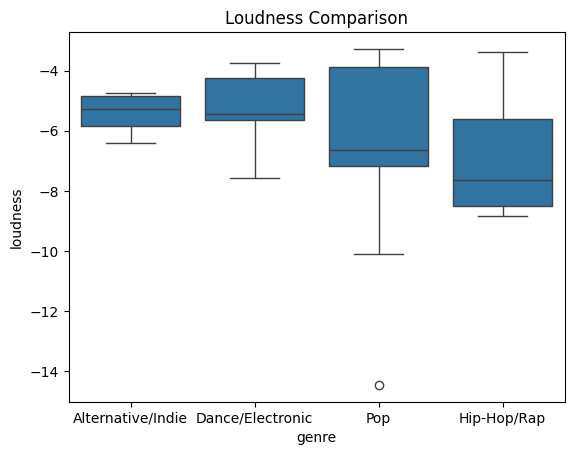

,genre,song_count
0,Pop,14
1,Hip-Hop/Rap,13
2,Dance/Electronic,5
3,Alternative/Indie,4


In [32]:
"""
How does the loudness score compare between
Pop, Hip-Hop/Rap, Dance/Electronic, and Alternative/Indie genres?
"""
relevant_genres = ["Pop", "Hip-Hop/Rap", "Dance/Electronic", "Alternative/Indie"]
filtered_df = df.loc[df.genre.isin(relevant_genres)]
loudness_comparison = (
    filtered_df.groupby(["genre"])
    .loudness.median()
    .sort_values(ascending=False)
    .index
)
sns.boxplot(
    data=filtered_df,
    x="genre",
    y="loudness",
    order=loudness_comparison
)
song_count_df = (
    filtered_df.groupby("genre")
    .genre.count()
    .sort_values(ascending=False)
    .reset_index(name="song_count")
)

plt.title("Loudness Comparison")
plt.show()
print("\n")
song_count_df

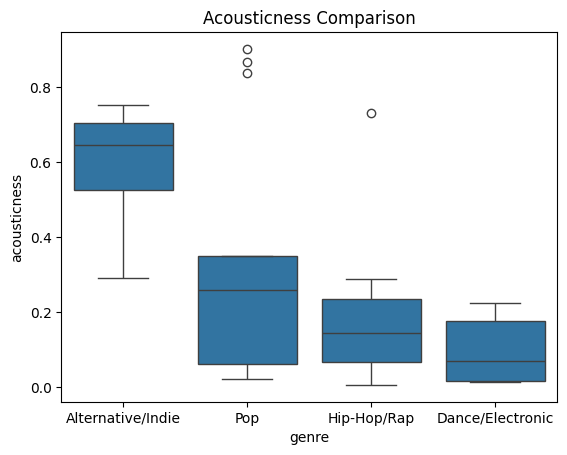

,genre,song_count
0,Pop,14
1,Hip-Hop/Rap,13
2,Dance/Electronic,5
3,Alternative/Indie,4


In [33]:
"""
How does the acoustics score compare between
Pop, Hip-Hop/Rap, Dance/Electronic, and Alternative/Indie genres?
"""
relevant_genres = ["Pop", "Hip-Hop/Rap", "Dance/Electronic", "Alternative/Indie"]
filtered_df = df.loc[df.genre.isin(relevant_genres)]
acousticness_comparison = (
    filtered_df.groupby(["genre"])
    .acousticness.median()
    .sort_values(ascending=False)
    .index
)
sns.boxplot(
    data=filtered_df,
    x="genre",
    y="acousticness",
    order=acousticness_comparison
)
song_count_df = (
    filtered_df.groupby("genre")
    .genre.count()
    .sort_values(ascending=False)
    .reset_index(name="song_count")
)

plt.title("Acousticness Comparison")
plt.show()
print("\n")
song_count_df

# Results



*   Top songs are mostly dance songs, independent of genre.

*   Top songs are mostly loud songs, with noteable exceptions like the Hip-Hop genre

*   Top songs are usually not accoustic, except for Alternative/Indie genre

*   Energy appears to be strongly positively correlated with loudness.

*   Energy appears to be strongly negatively correlated with accousticness.

*   54% of top songs are of Pop and Hip-Hop genre and 72% if we include Dance/Electronic and Alternative/Indie.

*   40 unique artists and 45 unique albums had an entry in the list.

*   Most of the features had outliers which ought to be transformed before the regression analysis.



# Ideas for Further Analysis


*   Do a regression analysis to find out whether songs valence impacts energy-loudness correlation.

